In [4]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import r2_score, root_mean_squared_error

from Flame_fun import crop_flame_region, FL_fun, process_flame_dataset

In [5]:
# Importation des données et mise en forme pour la POD
csv_path = "Data4ML.csv"
base_image_folder = ".\data"
imgs, mean_flame_image, FL_list = process_flame_dataset(csv_path,base_image_folder,1)
FL_array = np.array(FL_list)
FL_ref = FL_array.ravel()

Calcul de la SVD globale pour 25 modes...
Début de l'évaluation géométrique mode par mode...
-> Reconstructions et mesures avec 1 mode(s)...
-> Reconstructions et mesures avec 2 mode(s)...
-> Reconstructions et mesures avec 3 mode(s)...
-> Reconstructions et mesures avec 4 mode(s)...
-> Reconstructions et mesures avec 5 mode(s)...
-> Reconstructions et mesures avec 6 mode(s)...
-> Reconstructions et mesures avec 7 mode(s)...
-> Reconstructions et mesures avec 8 mode(s)...
-> Reconstructions et mesures avec 9 mode(s)...
-> Reconstructions et mesures avec 10 mode(s)...
-> Reconstructions et mesures avec 11 mode(s)...
-> Reconstructions et mesures avec 12 mode(s)...
-> Reconstructions et mesures avec 13 mode(s)...
-> Reconstructions et mesures avec 14 mode(s)...
-> Reconstructions et mesures avec 15 mode(s)...
-> Reconstructions et mesures avec 16 mode(s)...
-> Reconstructions et mesures avec 17 mode(s)...
-> Reconstructions et mesures avec 18 mode(s)...
-> Reconstructions et mesures avec

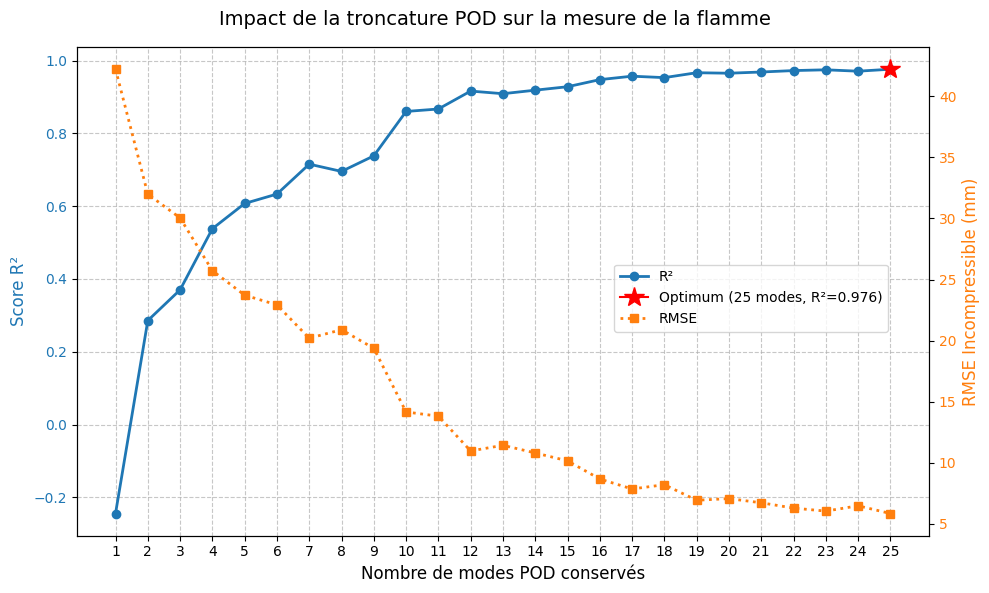

In [6]:
## Évaluation de la précision maximale possible pour un nombre de mode donné.

warnings.filterwarnings("ignore")

# Initialisation des variables et listes pour stockage
max_modes = 25
modes_list = list(range(1, max_modes + 1))
r2_list = []
rmse_list = []

print(f"Calcul de la SVD globale pour {max_modes} modes...")
svd = TruncatedSVD(n_components=max_modes, algorithm='randomized', random_state=42)
alphas_exact = svd.fit_transform(imgs)
Vt = svd.components_
variance_cumulee = np.cumsum(svd.explained_variance_ratio_) * 100 

print("Début de l'évaluation géométrique mode par mode...")

# Pour chaque nombre de modes conservés, on reconstruit les images
# puis on recalcule la longueur de flamme sur ces reconstructions.
for k in modes_list:
    print(f"-> Reconstructions et mesures avec {k} mode(s)...")
    imgs_recon_k = (alphas_exact[:, :k] @ Vt[:k, :])
    FL_calc_k = []
    
    for img in imgs_recon_k:
        # Recentrage autour de l'image moyenne puis remise au format 2D        
        img_2D = mean_flame_image + img.reshape(mean_flame_image.shape)
        
        # Conversion propre pour OpenCV
        img_2D_clipped = np.clip(img_2D, 0, 255).astype(np.uint8)
        
        # Mesure de la longueur sur l'image reconstruite
        longueur = FL_fun(img_2D_clipped)
        FL_calc_k.append(longueur)
        
    FL_calc_k = np.array(FL_calc_k)
    
    # Évaluation de la perte d'information géométrique due à la troncature
    r2_list.append(r2_score(FL_ref, FL_calc_k))
    rmse_list.append(root_mean_squared_error(FL_ref, FL_calc_k))

# Meilleur compromis selon le R² obtenu
best_k = modes_list[np.argmax(r2_list)]
best_r2 = np.max(r2_list)
best_rmse = np.min(rmse_list)

print("\n" + "="*50)
print("LIMITE THÉORIQUE DE LA POD :")
print(f" R² maximum est {best_r2:.4f} (atteint à {best_k} modes)")
print(f" RMSE est {best_rmse:.2f} mm")
print("="*50)

# Tracé de l'évolution des performances avec le nombre de modes

# R² sur l'axe principal
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('Nombre de modes POD conservés', fontsize=12)
ax1.set_ylabel('Score R²', color=color, fontsize=12)
ax1.plot(modes_list, r2_list, marker='o', color=color, linewidth=2, label='R²')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(modes_list)
ax1.grid(True, linestyle='--', alpha=0.7)

# Mise en évidence du meilleur résultat
ax1.plot(best_k, best_r2, marker='*', color='red', markersize=15, zorder=5,
         label=f'Optimum ({best_k} modes, R²={best_r2:.3f})')

# RMSE sur l'axe secondaire
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('RMSE Incompressible (mm)', color=color, fontsize=12)  
ax2.plot(modes_list, rmse_list, marker='s', linestyle=':', color=color, linewidth=2, label='RMSE')
ax2.tick_params(axis='y', labelcolor=color)

fig.suptitle('Impact de la troncature POD sur la mesure de la flamme', fontsize=14)
fig.legend(loc="center right", bbox_to_anchor=(0.9, 0.5))
fig.tight_layout()  
plt.show()

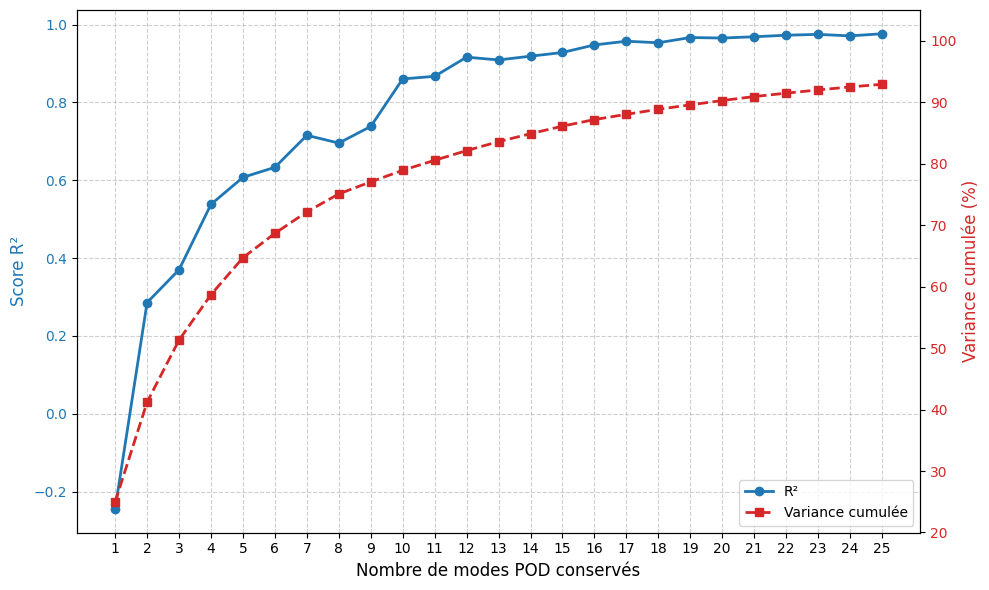

In [7]:
## Tracé du graph R² VS Variance cumulée 

fig, ax1 = plt.subplots(figsize=(10, 6))

# R² sur l'axe principal
color_r2 = 'tab:blue'
ax1.set_xlabel('Nombre de modes POD conservés', fontsize=12)
ax1.set_ylabel('Score R²', color=color_r2, fontsize=12)
line1, = ax1.plot(modes_list, r2_list, marker='o', color=color_r2, linewidth=2, label='R²')
ax1.tick_params(axis='y', labelcolor=color_r2)
ax1.set_xticks(modes_list)
ax1.grid(True, linestyle='--', alpha=0.6)

# Variance cumulée sur l'axe secondaire
ax2 = ax1.twinx()
color_var = 'tab:red'
ax2.set_ylabel('Variance cumulée (%)', color=color_var, fontsize=12)
line2, = ax2.plot(modes_list, variance_cumulee, marker='s', linestyle='--', color=color_var, linewidth=2, label='Variance cumulée')
ax2.tick_params(axis='y', labelcolor=color_var)
ax2.set_ylim(min(variance_cumulee)-5, 105) 

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="lower right")

fig.tight_layout()
plt.show()

In [9]:
def eval_POD(U,S,Vt,n_modes_to_plot=5,scree_plot=True) :
    """
    Input:
        U (np.ndarray): Matrice des modes temporels / coefficients à gauche de la SVD
        S (np.ndarray): Valeurs singulières
        Vt (np.ndarray): Matrice des modes spatiaux transposés
        n_modes_to_plot (int): Nombre de modes spatiaux à afficher
        scree_plot (bool): Si True, affiche le scree plot des énergies

    Output:
        None: Affiche le scree plot et les premiers modes spatiaux de la POD
    """
    # Les valeurs propres (énergie des modes) sont le carré des valeurs singulières
    eigenvalues = S**2

    # Fraction d'énergie capturée par chaque mode (%)
    energy_frac = eigenvalues / np.sum(eigenvalues) * 100
    
    # Énergie cumulée → permet de voir combien de modes sont nécessaires
    cumulative_energy = np.cumsum(energy_frac)
    
    if scree_plot :
        
        # On limite l'affichage aux 20 premiers modes pour garder une lecture claire
        plt.figure(figsize=(10, 5))
        modes_x = np.arange(1, min(21, len(energy_frac) + 1)) 
        
        # Barres : contribution individuelle de chaque mode
        plt.bar(modes_x, energy_frac[:20], alpha=0.7, label='Énergie individuelle', color='blue')
        # Courbe : variance cumulée → critère classique en POD
        plt.plot(modes_x, cumulative_energy[:20], marker='o', color='red', label='Énergie cumulée')
            
        plt.axhline(y=90, color='k', linestyle='--', label='Seuil 90%')
        plt.axhline(y=95, color='gray', linestyle='--', label='Seuil 95%')
            
        plt.title("Scree Plot : Variance capturée par les modes POD")
        plt.xlabel("Numéro du mode POD")
        plt.ylabel("Variance (%)")
        plt.xticks(modes_x)
        plt.legend()
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    
    # Tracé des premiers modes spatiaux
    fig, axes = plt.subplots(1, n_modes_to_plot, figsize=(4 * n_modes_to_plot, 8))
        
    # Sécurité si un seul mode est demandé
    if n_modes_to_plot == 1:
        axes = [axes] 
            
    for i in range(n_modes_to_plot):
        # Reconstruction du mode spatial i sous forme d'image (les modes sont stockés vectorisés dans Vt).
        mode_img = Vt[i,:1710*700].reshape((1710, 700))
        vmax = np.max(np.abs(mode_img))
        
        # Échelle symétrique → important pour visualiser structures +/- (fluctuations)
        vmin = -vmax
            
        im = axes[i].imshow(mode_img, cmap='seismic', vmin=vmin, vmax=vmax)
        
        # On affiche aussi la variance associée au mode
        axes[i].set_title(f"Mode {i+1}\nVariance : {energy_frac[i]:.2f}%")
        fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
            
    plt.tight_layout()
    plt.show()

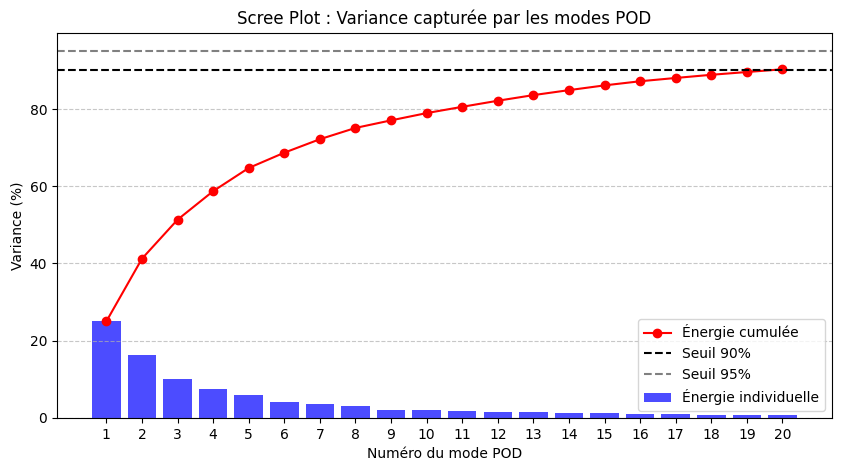

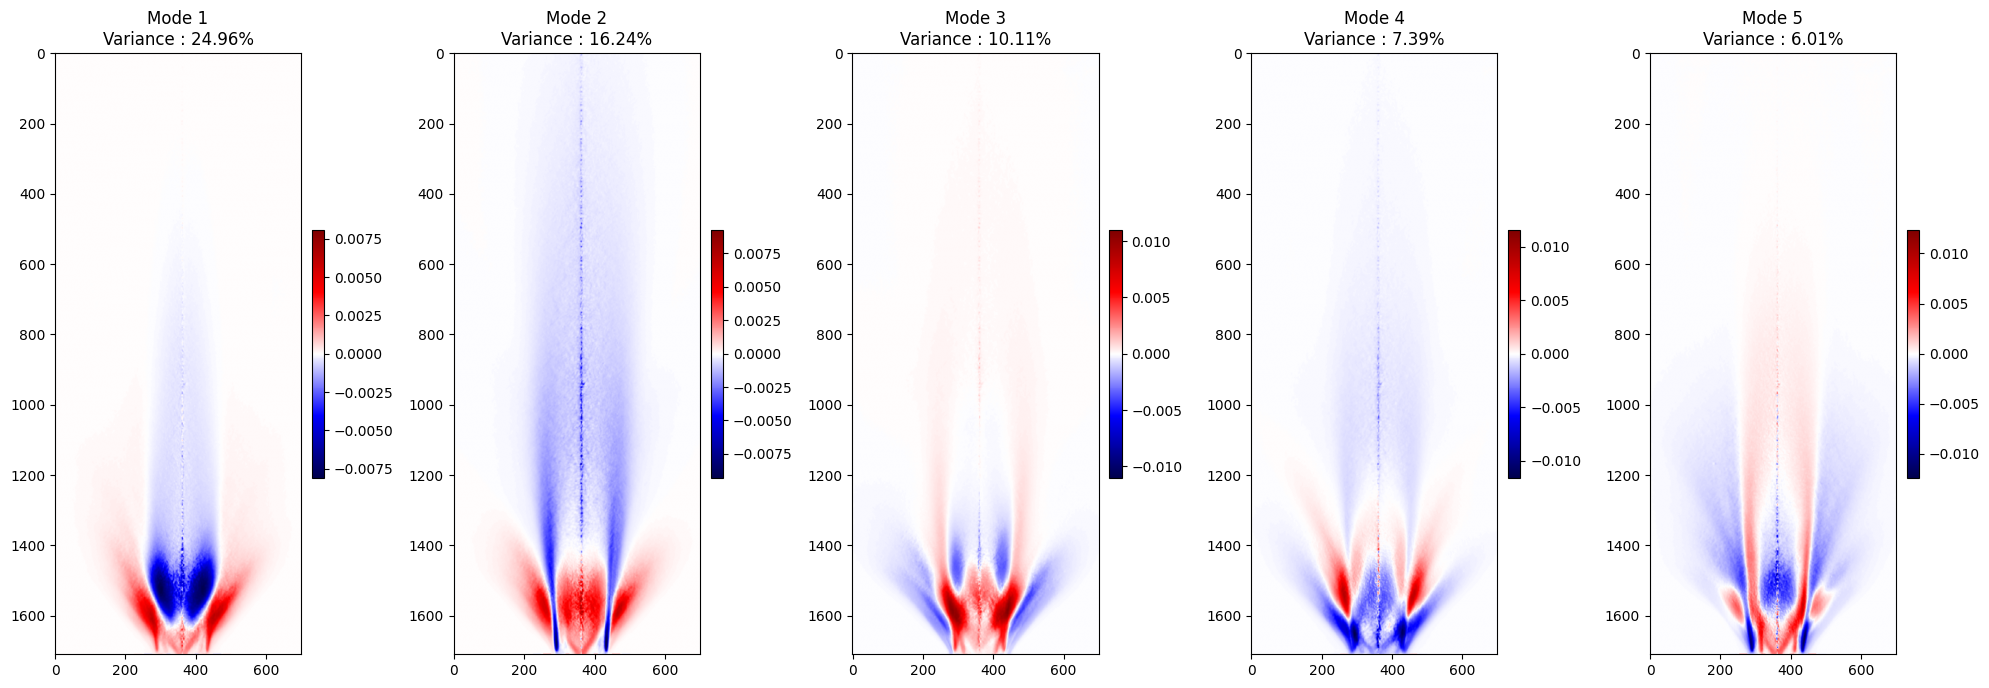

In [10]:
## Applicationd la fonction pour les 5 premiers modes :
U, S, Vt = np.linalg.svd(imgs, full_matrices=False)
eval_POD(U,S,Vt,5)